# 01 — Data preparation

Inspect raw data and cleaning results.

From project root:
```bash
python -m src.cleaning
```

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().parent if (Path.cwd().parent / "src").exists() else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import CLEANED_ROOT, RAW_ROOT, STATS_DIR

LANG = "kidawida"
RAW = RAW_ROOT / LANG
CLEAN = CLEANED_ROOT / LANG

In [2]:
# Raw split sizes
for split in ("train", "dev", "test"):
    for ext in ("tsv", "jsonl", "json"):
        p = RAW / f"{split}.{ext}"
        if p.exists():
            if ext == "tsv":
                df = pd.read_csv(p, sep="\t")
            elif ext == "jsonl":
                df = pd.read_json(p, lines=True)
            else:
                df = pd.DataFrame(json.loads(p.read_text()))
            print(f"{split}.{ext}: {len(df)} rows | cols: {list(df.columns)[:5]}...")
            display(df.head(2))
            break

train.tsv: 2098 rows | cols: ['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain']...


,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,a9da6d8429f03ce96feed5c108c4940c7eaf45b424885a...,common_voice_dav_40688698.mp3,1a7979730b1876b82bc141728cfe23f59ef9c1ff160654...,Wakarilwa na kumarwa ni izi toe.,healthcare,2,0,twenties,NaN,NaN,NaN,dav,NaN
1,a9da6d8429f03ce96feed5c108c4940c7eaf45b424885a...,common_voice_dav_41079948.mp3,38b1365a236cbf4b435d546167e6d5e653af4f33904b4b...,"W'ana ndew'iuzwa, w'anekwa mundu ulele.",general,2,0,twenties,NaN,NaN,NaN,dav,NaN


dev.tsv: 1276 rows | cols: ['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain']...


,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,712eef8f116e6302fd5f67dd2720b34724809467f1bc05...,common_voice_dav_40766996.mp3,21511762ec289a4ae5a7f17ff6702a2d7b89ff6bcfcbd8...,Nani wakuzera kukame mnyinya,general,2,0,thirties,NaN,NaN,NaN,dav,NaN
1,712eef8f116e6302fd5f67dd2720b34724809467f1bc05...,common_voice_dav_40763566.mp3,21141f01c6c9f1a3dd6f54f5d2bde980c50b25b706aba7...,Inyo w'ele mwadanitegemea ini tu?,general,2,0,thirties,NaN,NaN,NaN,dav,NaN


test.tsv: 1004 rows | cols: ['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain']...


,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,58f7ae64f2b3492ea42645464f453db36397d034ef7edf...,common_voice_dav_40729419.mp3,1f0a7f17c3f258db37db2f96a99e092be06c1c6fd4ebb6...,Nedemba niw'uduke mtaronyi,general,2,0,sixties,female_feminine,NaN,NaN,dav,NaN
1,58f7ae64f2b3492ea42645464f453db36397d034ef7edf...,common_voice_dav_40705018.mp3,1b901a4ecaa08ddb6ce1683e5b91df412a6ae3e960a9be...,W'urumwengu ghodu ghokunda kulindilwa,nature_environment,2,0,sixties,female_feminine,NaN,NaN,dav,NaN


In [3]:
# Verify results (stored inside cleaning_report.json)
cr = STATS_DIR / "cleaning_report.json"
if cr.exists():
    verify = json.loads(cr.read_text())[0].get("verify", {})
    print(f"Verify OK: {verify.get('ok', '?')}")
    for s, info in verify.get("splits", {}).items():
        print(f"  {s}: {info.get('manifest', '?')} rows={info['rows']} missing={info['missing_audio']}")
else:
    print("Run: python -m src.cleaning")

Verify OK: True
  train: train.tsv rows=2098 missing=0
  dev: dev.tsv rows=1276 missing=0
  test: test.tsv rows=1004 missing=0


,split,input,kept,too_short
0,train,2098,1639,459
1,dev,1276,1080,196
2,test,1004,964,40


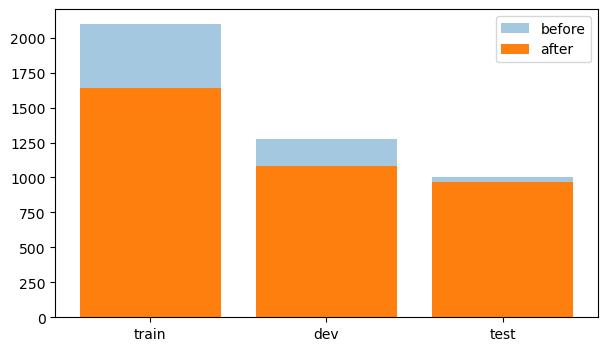

In [4]:
# Cleaning results
cr = STATS_DIR / "cleaning_report.json"
if cr.exists():
    stats = json.loads(cr.read_text())[0]["splits"]
    df = pd.DataFrame([{"split": s, **v} for s, v in stats.items()])
    display(df[["split", "input", "kept", "too_short"]])
    fig, ax = plt.subplots(figsize=(7, 4))
    x = range(len(df))
    ax.bar(x, df["input"], alpha=0.4, label="before")
    ax.bar(x, df["kept"], label="after")
    ax.set_xticks(list(x), df["split"])
    ax.legend()
    fig.savefig(ROOT / "outputs" / "figures" / "cleaning_comparison.png", dpi=120)
    plt.show()
else:
    print("Run: python -m src.cleaning")

In [5]:
# Cleaned sample
train = CLEAN / "manifests" / "train.tsv"
if train.exists():
    display(pd.read_csv(train, sep="\t")[["path", "sentence", "duration_sec"]].head())

,path,sentence,duration_sec
0,common_voice_dav_40688698.mp3,Wakarilwa na kumarwa ni izi toe.,4.5435
1,common_voice_dav_41079948.mp3,"W'ana ndew'iuzwa, w'anekwa mundu ulele.",4.4355
2,common_voice_dav_40572995.mp3,Mka obanda sa mlamba.,7.0275
3,common_voice_dav_40572954.mp3,Jiwike kula na mwai wa w'andu.,4.0035
4,common_voice_dav_41052705.mp3,Mundu wa w'omi wapo oka na mka mzima cha shighadi,6.4155


In [ ]:
# check the transcript for specific clip common_voice_dav_40740310

